In [1]:
import sys
import pandas as pd
import numpy as np
import scanpy as sc

from sklearn.cluster import KMeans
import scipy.stats
from itertools import combinations
from sklearn.metrics import pairwise_distances

import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'axes.labelsize' : 'large'}) 
from matplotlib.backends.backend_pdf import PdfPages

import sys
import os

from tqdm import tqdm
from tqdm.contrib.concurrent import process_map

import gc
import warnings
import time
import pickle

from sklearn.metrics import pairwise_distances
from multiprocessing import Pool
import torch

from importlib import reload
import util_functions

/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
!nvidia-smi

Sat Jul  6 11:33:28 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.14              Driver Version: 550.54.14      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:03:00.0 Off |                    0 |
| N/A   24C    P0             25W /  250W |     153MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

<h2>sgRNA filtering Version 3</h2>
1. Aggregate sgRNAs per genes<br>
2. Permute 1000times & use 10 random non-targeting background = Total 10000 permutation/ TF<br>
3. Calculate p-value by (total number of observed > shuffle for each background) / Total permutation<br>

In [3]:
torch.cuda.empty_cache

<function torch.cuda.memory.empty_cache() -> None>

In [4]:
!free -m

              total        used        free      shared  buff/cache   available
Mem:         257929        7322      249236          66        1369      249212
Swap:        131071         333      130738


In [5]:
reload(util_functions)
input_file = "/project/shared/gcrb_igvf/data/shared/TF_Perturbseq_full/H5AD/V0.1_TF_Perturbseq_full_sgRNACells_filtered_w_embedding_full_dataset.h5ad"
sgRNA_file = "/project/GCRB/Hon_lab/s215194/Single_Cell/TF_perturbseq_full/_all_lanes_combined/aggr_dataframe/aggr_combined_df_full.pkl"
dict_file = "./gRNA_dict.pickle"
pca_file = "./pca_dataframe.pickle"
non_target_file = "./non_target_cell_name.pickle"

obsm_key = "X_pca"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

(X,gRNA_dict) = util_functions.load_files(input_file,sgRNA_file,dict_file,pca_file,obsm_key)

read input
read pickle
read from dictionary


In [6]:
sgRNA_outlier_clear_df = pd.read_csv("sgRNA_outlier_dist_clear_v3.csv",index_col=0)

In [7]:
sgRNA_outlier_clear_df.head()

,pval_outlier
ADNP2_-_77867536.23-P1P2-1,1.0
ADNP2_-_77867536.23-P1P2-2,1.0
ADNP2_-_77867648.23-P1P2-2,1.0
AEBP1_+_44143999.23-P1P2-1,1.0
AEBP1_+_44143999.23-P1P2-2,1.0


In [8]:
gRNA_per_transcript_dict = {}
cell_per_transcript_dict = {}

cell_num_dict_gRNA = {}

for key in sgRNA_outlier_clear_df.index:
    transcript_name = util_functions.extract_transcript_name(key)

    num_cell = len(gRNA_dict[key])
    cell_num_dict_gRNA[key] = num_cell
    
    if num_cell > 20:
        if transcript_name in gRNA_per_transcript_dict.keys():
            gRNA_per_transcript_dict[transcript_name] += [key].copy()
            cell_per_transcript_dict[transcript_name] += gRNA_dict[key].copy()
        else:
            gRNA_per_transcript_dict[transcript_name] = [key].copy()
            cell_per_transcript_dict[transcript_name] = gRNA_dict[key].copy()

In [9]:
len(gRNA_per_transcript_dict.keys())

2092

In [10]:
cell_num_dict_transcript = {}

for key in cell_per_transcript_dict.keys():
    num_cell = len(cell_per_transcript_dict[key])
    cell_num_dict_transcript[key] = num_cell

In [11]:
cell_num_df = pd.DataFrame(cell_num_dict_gRNA,index=["Count"]).T
cell_num_df.to_csv("cell_number_per_sgRNA.csv")

cell_num_df = pd.DataFrame(cell_num_dict_transcript,index=["Count"]).T
cell_num_df.to_csv("cell_number_per_transcript.csv")

<h3>Select good non-target gRNA using K-means</h3>

In [12]:
non_target_gRNA_list = [item for item in list(gRNA_dict.keys()) 
                        if (item.startswith("non-targeting")) and 
                        (len(gRNA_dict[item])>20)]
cell_id_nontarget_list = [gRNA_dict[key] for key in non_target_gRNA_list]

In [13]:
res = util_functions.pairwise_torch(X,cell_id_nontarget_list,device)

100%|██████████| 1559/1559 [00:08<00:00, 175.54it/s]


In [14]:
!nvidia-smi

Fri Jun 14 13:14:40 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.14              Driver Version: 550.54.14      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-PCIE-32GB           Off |   00000000:3B:00.0 Off |                    0 |
| N/A   31C    P0             43W /  250W |    1235MiB /  32768MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [15]:
len(cell_id_nontarget_list)

558

In [16]:
# make Dataframe from results
pairwise_list = np.zeros((len(non_target_gRNA_list),
                          len(non_target_gRNA_list)
                         ))
for p1, p2, val in tqdm(res):
    pairwise_list[p1,p2]=val
    pairwise_list[p2][p1]=val
df = pd.DataFrame(pairwise_list.copy(),
                  index=non_target_gRNA_list,
                  columns=non_target_gRNA_list) 

df.index.name = "sgRNA"
df.columns.name = "sgRNA"
df.name = 'pairwise PCA distances'

sigmas = np.diag(df)
deltas = df
target_estats = 2 * deltas - sigmas - sigmas[:, np.newaxis]
target_estats = target_estats.abs()

kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(target_estats)
label,count = np.unique(kmeans.labels_,return_counts=True)
print(label,count)
#This is the non-target list for TF perturb seq
non_target_gRNA_name = target_estats.index.to_numpy()[kmeans.labels_ == label[np.argmax(count)]]

100%|██████████| 155961/155961 [00:00<00:00, 1373374.41it/s]


[0 1 2] [ 95   1 462]


In [17]:
non_target_gRNA_name_df = pd.Series(non_target_gRNA_name)
non_target_gRNA_name_df.to_csv("non_target_gRNA_list.csv",index=None)

<h3>Calculate p-values with Permutation test</h3>

1. Aggregate per transcript<br>
2. Calculate Distance between non-target<br>
2. Mix and sample picking same number as test and control
3. Calculate e-distance between two samples
4. Repeat 1000times(100000times in the future)

In [18]:
!nvidia-smi

Fri Jun 14 13:14:41 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.14              Driver Version: 550.54.14      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-PCIE-32GB           Off |   00000000:3B:00.0 Off |                    0 |
| N/A   31C    P0             42W /  250W |    1235MiB /  32768MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [19]:
transcript_small_list = []
transcript_large_list = []
for key in cell_per_transcript_dict:
    num_cells = len(cell_per_transcript_dict[key])
    if num_cells < 1000:
        transcript_small_list.append(key)
    else:
        transcript_large_list.append(key)

print(len(transcript_small_list))
print(len(transcript_large_list))
print("Total:",len(transcript_small_list) + len(transcript_large_list))

1908
184
Total: 2092


In [15]:
reload(util_functions)
permute_per_bg = 1000
num_of_bg = 20
non_target_pick = 2000

batch_num = 200

In [14]:
pval_dict = {}
non_target_cell_name = [gRNA_dict[i] for i in non_target_gRNA_name]

#concatenate all list together
non_target_cell_name = sum(non_target_cell_name,[])

#unique cell id list
non_target_cell_name = sorted(list(set(non_target_cell_name)))
pd.Series(non_target_cell_name).to_csv("non_targeting_background_full_v3.csv")

NameError: name 'non_target_gRNA_name' is not defined

In [21]:
#fix random cell with seed
np.random.seed(0)

non_target_cell_name_reduced = []

for i in range(num_of_bg):
    non_target_cell_name_reduced.append(np.random.choice(non_target_cell_name,non_target_pick))

In [22]:
pd.DataFrame(non_target_cell_name_reduced).to_csv("non_targeting_background_v3.csv")

In [23]:
output_file = "pval_transcript_full_v3.csv"

In [24]:
for transcript_index, transcript_name in enumerate(tqdm(transcript_small_list)):
    target_cell_name = cell_per_transcript_dict[transcript_name]
    
    for bg_index in range(num_of_bg):
        overlap = set(target_cell_name) & set(non_target_cell_name_reduced[bg_index])
        non_target_cell_name_clear = list(set(non_target_cell_name_reduced[bg_index])-overlap)
        target_cell_name_clear = list(set(target_cell_name)-overlap)
        (obs_edist,e_dist_list) = util_functions.permutation_test(X,target_cell_name_clear,
                                                                  non_target_cell_name_clear,
                                                                  device,
                                                                  batch_num,
                                                                  permute_per_bg)
        
        if transcript_name not in pval_dict.keys():
            pval_dict[transcript_name] = {}
        pval_dict[transcript_name]["distance_"+str(bg_index)] = obs_edist.item()
        pval_dict[transcript_name]["pval_"+str(bg_index)] = (e_dist_list>obs_edist).sum().item()/permute_per_bg

    if transcript_index % 10 == 0:
        pd.DataFrame(pval_dict).T.to_csv(output_file)
            
#Use samll butches for sgRNA with many cells (memory problem)
batch_num = 20

for transcript_index, transcript_name in enumerate(tqdm(transcript_large_list)):
    target_cell_name = cell_per_transcript_dict[transcript_name]
    
    for bg_index in range(num_of_bg):
        overlap = set(target_cell_name) & set(non_target_cell_name_reduced[bg_index])
        non_target_cell_name_clear = list(set(non_target_cell_name_reduced[bg_index])-overlap)
        target_cell_name_clear = list(set(target_cell_name)-overlap)
        (obs_edist,e_dist_list) = util_functions.permutation_test(X,target_cell_name_clear,
                                                                  non_target_cell_name_clear,
                                                                  device,
                                                                  batch_num,
                                                                  permute_per_bg)
        
        if transcript_name not in pval_dict.keys():
            pval_dict[transcript_name] = {}
        pval_dict[transcript_name]["distance_"+str(bg_index)] = obs_edist.item()
        pval_dict[transcript_name]["pval_"+str(bg_index)] = (e_dist_list>obs_edist).sum().item()/permute_per_bg

    if transcript_index % 10 == 0:
        pd.DataFrame(pval_dict).T.to_csv(output_file)

pd.DataFrame(pval_dict).T.to_csv(output_file)

  0%|          | 6/1908 [00:51<4:31:19,  8.56s/it]


KeyboardInterrupt: 

<h3>Stat of the result</h3>

In [16]:
output_file = "pval_transcript_full_v3.csv"
#result_df = pd.DataFrame(pval_dict).T
result_df = pd.read_csv(output_file,index_col=0)

In [17]:
result_df["pval_mean"] = result_df.iloc[:,list(range(1,num_of_bg*2,2))].mean(axis=1)
result_df["pval_std"] = result_df.iloc[:,list(range(1,num_of_bg*2,2))].std(axis=1)

result_df["distance_mean"] = result_df.iloc[:,list(range(0,num_of_bg*2,2))].mean(axis=1)
result_df["distance_std"] = result_df.iloc[:,list(range(0,num_of_bg*2,2))].std(axis=1)

In [18]:
result_df["pval_mean_log"] = -np.log10(result_df["pval_mean"]+0.00001)
result_df["distance_mean_log"] = np.log10(result_df["distance_mean"])

In [19]:
result_df.to_csv(output_file)

<Axes: xlabel='distance_mean_log', ylabel='pval_mean_log'>

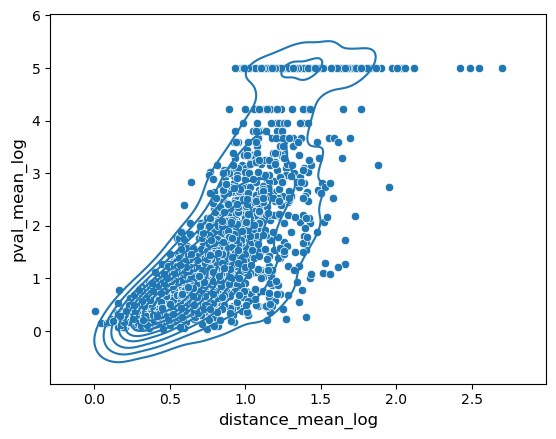

In [20]:
sns.scatterplot(data=result_df,x="distance_mean_log",y="pval_mean_log")
sns.kdeplot(data=result_df,x="distance_mean_log",y="pval_mean_log")

<Axes: xlabel='pval_mean_log', ylabel='Count'>

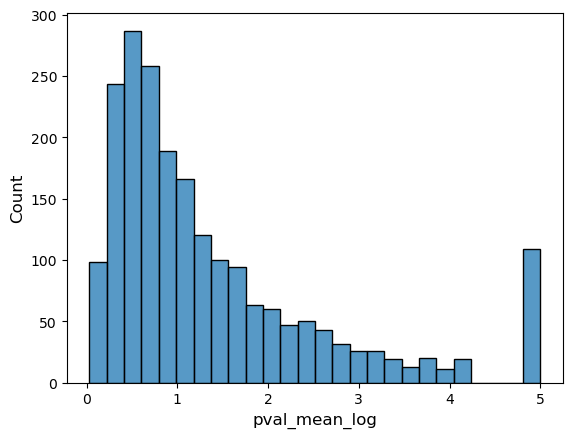

In [36]:
sns.histplot(result_df["pval_mean_log"])

<h3>Find cutoff</h3>

In [22]:
estat_transcript = result_df

estat_transcript["gene_name"] = estat_transcript.index.map(lambda x:x.split(":")[0])

p_val_cutoff_list = [1,0.1,0.05,0.01,0.005,0.001]
dist_cut_off_list = [0,5,10,12,15,20,30,50]
cut_off_df = pd.DataFrame(index=p_val_cutoff_list,columns=dist_cut_off_list)
cut_off_OR_df = pd.DataFrame(index=p_val_cutoff_list,columns=dist_cut_off_list)

for p_val_cutoff in p_val_cutoff_list:
    for dist_cut_off in dist_cut_off_list:
        estat_transcript_sig = estat_transcript[(estat_transcript["distance_mean"]>dist_cut_off) & 
                                               (estat_transcript["pval_mean"]<=p_val_cutoff )]
        transcript_sig_list = estat_transcript_sig.index.tolist()
        gene_sig_list = np.unique(estat_transcript_sig["gene_name"])
        
        is_OR = [x.startswith("OR") and x != "ORAI1" for x in gene_sig_list]
        OR_num = sum(is_OR)
        
        cut_off_df.at[p_val_cutoff,dist_cut_off] = len(gene_sig_list)
        cut_off_OR_df.at[p_val_cutoff,dist_cut_off] = OR_num

In [23]:
cut_off_df

,0,5,10,12,15,20,30,50
1.000,1899,1021,434,341,247,155,72,32
0.100,966,841,400,315,235,151,72,32
0.050,755,710,375,295,226,142,67,32
0.010,450,447,321,261,205,131,66,32
0.005,363,361,278,235,190,122,63,31
0.001,223,223,199,176,153,105,56,30


In [24]:
cut_off_OR_df

,0,5,10,12,15,20,30,50
1.000,97,44,10,7,2,1,0,0
0.100,36,35,9,6,1,1,0,0
0.050,28,28,8,6,1,1,0,0
0.010,10,10,6,6,1,1,0,0
0.005,6,6,6,6,1,1,0,0
0.001,3,3,3,3,1,1,0,0


<h3>Filtering out low expression TFs</h3>

In [25]:
dist_cut_off = 0
p_val_cutoff = 0.001

estat_transcript_sig = estat_transcript[(estat_transcript["distance_mean"]>dist_cut_off) & 
                                       (estat_transcript["pval_mean"]<p_val_cutoff)]
transcript_sig_list = estat_transcript_sig.index.tolist()
gene_sig_list = np.unique(estat_transcript_sig["gene_name"])

In [34]:
result_df["Significant"] = ["Yes" if i in transcript_sig_list else "No" for i in result_df.index]

<Axes: xlabel='distance_mean_log', ylabel='pval_mean_log'>

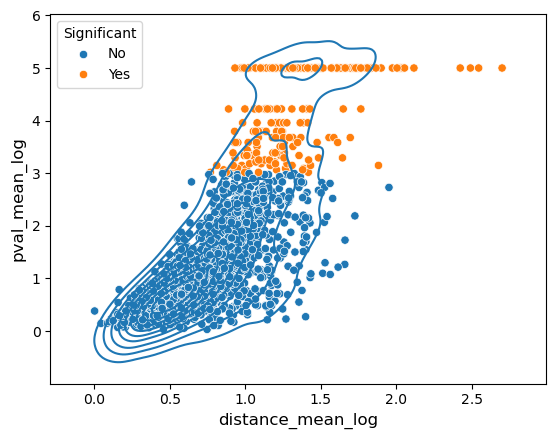

In [37]:
sns.scatterplot(data=result_df,x="distance_mean_log",y="pval_mean_log",
                hue="Significant",hue_order=["No","Yes"])
sns.kdeplot(data=result_df,x="distance_mean_log",y="pval_mean_log")

In [42]:
input_file = "/project/shared/gcrb_igvf/data/shared/TF_Perturbseq_full/H5AD/V0.1_TF_Perturbseq_full_sgRNACells_filtered_w_embedding_full_dataset.h5ad"
input_data = sc.read_h5ad(input_file,chunk_size=100000000)

In [43]:
total_gene_list = np.unique(input_data.var.index)
print(gene_sig_list[~np.isin(gene_sig_list,total_gene_list)])

['APITD1' 'CRAMP1L' 'HELT' 'OR2T29' 'OR8B4' 'TCEB3']


In [44]:
#CRAMP1L -> CRAMP1, TCEB3->ELOA
remove_list = ["HELT","OR2T29","OR4Q3","OR8B4","PHOX2B"]
gene_list_for_scanpy = gene_sig_list.copy()
gene_list_for_scanpy[gene_list_for_scanpy=="CRAMP1L"] = "CRAMP1"
gene_list_for_scanpy[gene_list_for_scanpy=="TCEB3"] = "ELOA"
gene_list_for_scanpy[gene_list_for_scanpy=="CD29"] = "ITGB1"
gene_list_for_scanpy[gene_list_for_scanpy=="PRKRIR"] = "THAP12"
gene_list_for_scanpy[gene_list_for_scanpy=="APITD1"] = "CENPS"
gene_list_for_scanpy[np.isin(gene_list_for_scanpy,remove_list)] = ""

In [45]:
expression_list = np.array(
    [input_data.var.loc[name,"mean"] if name in input_data.var.index else 1e-6 for name in gene_list_for_scanpy]
)

<Axes: ylabel='Count'>

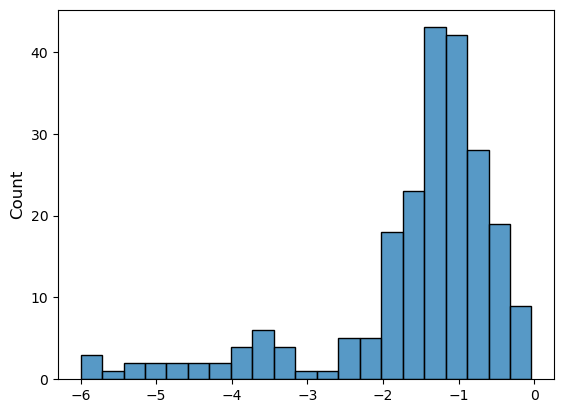

In [46]:
sns.histplot(np.log10(expression_list))

In [47]:
print("filtered:",gene_sig_list[expression_list < 1e-4])
gene_list_clean = gene_sig_list[expression_list > 1e-4]

filtered: ['BHLHA9' 'CDX2' 'CDX4' 'DBX2' 'FEZF2' 'FOXD3' 'HELT' 'HOXA1' 'NOTO'
 'OR2T29' 'OR6P1' 'OR8B4' 'RBPJL' 'ZNF471']


In [55]:
estat_transcript_sig_clean = estat_transcript_sig[
    estat_transcript_sig["gene_name"].isin(gene_list_clean)
]

In [56]:
sgRNA_sig_list_tmp = [gRNA_per_transcript_dict[x] for x in estat_transcript_sig_clean.index]
cell_sig_list_tmp = [[gRNA_dict[x] for x in a]  for a in sgRNA_sig_list_tmp]

estat_transcript_sig_clean["num_sgRNA"] = [len(x) for x in sgRNA_sig_list_tmp]
estat_transcript_sig_clean["num_cells"] = [len(np.concatenate(x)) for x in cell_sig_list_tmp]

/tmp/ipykernel_277989/1011423464.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  estat_transcript_sig_clean["num_sgRNA"] = [len(x) for x in sgRNA_sig_list_tmp]
/tmp/ipykernel_277989/1011423464.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  estat_transcript_sig_clean["num_cells"] = [len(np.concatenate(x)) for x in cell_sig_list_tmp]


In [57]:
estat_transcript_sig_clean.to_csv("p_val_gRNA_sig_full_expressing_v3.csv")